# **EEG Coregistration**
 
 In this module, you'll learn how to:
 - Understand what coregistration means in EEG
 - Load and inspect electrode positions
 - Visualize electrodes in 2D (topomap) 
 - Align electrode positions with a standard brain template
 - Prepare spatial information for source localization

### **What is Coregistration?** 
 Coregistration aligns your electrode positions with a 3D model of the head/brain.
 This is essential for:
 - Understanding WHERE on the scalp each electrode is located
 - Source localization (estimating where brain activity originates)
 - Creating publication-quality figures

In [3]:

# Import required libraries
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configure display
%matplotlib inline
mne.set_log_level('WARNING')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## **Step 1:** Load the Sample Data
 
 We'll continue with the MNE sample dataset that already has electrode positions defined.

In [4]:
# Load sample data
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample',
                                     'sample_audvis_raw.fif')

# Load and select EEG channels
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)
raw = raw.pick(['eeg', 'eog', 'stim'])

print(f"✅ Loaded data with {len(mne.pick_types(raw.info, eeg=True))} EEG channels")


✅ Loaded data with 59 EEG channels



## **Step 2:** Understanding the Montage
 
 A **montage** defines where each electrode is positioned on the scalp.
 The sample data uses the standard "10-20" system, which you'll see in most EEG studies.

In [5]:
# Check if montage is already set
if raw.info['dig'] is not None:
    print("✅ Montage is already set in this dataset!")
    print(f"   Number of digitization points: {len(raw.info['dig'])}")
else:
    print("⚠️  No montage found - we'll set one manually")

# Let's see what montage is being used
montage = raw.get_montage()
if montage is not None:
    print(f"\n📍 Montage information:")
    print(f"   Name: {montage}")
    print(f"   Number of channels: {len(montage.ch_names)}")
    print(f"   First few channels: {montage.ch_names[:5]}")


✅ Montage is already set in this dataset!
   Number of digitization points: 146

📍 Montage information:
   Name: <DigMontage | 78 extras (headshape), 4 HPIs, 3 fiducials, 60 channels>
   Number of channels: 60
   First few channels: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']


## **Step 3:** Extract and Analyze Channel Positions
 
 Let's look at the actual 3D coordinates of each electrode.


In [6]:
# Get channel positions
montage = raw.get_montage()
pos = montage.get_positions()

# Extract electrode positions
ch_pos = pos['ch_pos']  # Dictionary: channel_name -> [x, y, z] coordinates

# Convert to array for analysis
eeg_channels = [ch for ch in raw.ch_names if ch in ch_pos]
positions_array = np.array([ch_pos[ch] for ch in eeg_channels])

print(f"📊 Channel Position Statistics:")
print(f"   Number of EEG electrodes: {len(eeg_channels)}")
print(f"   Coordinate system: Cartesian (x, y, z) in meters")
print(f"\n   X range: {positions_array[:, 0].min():.3f} to {positions_array[:, 0].max():.3f} m")
print(f"   Y range: {positions_array[:, 1].min():.3f} to {positions_array[:, 1].max():.3f} m")
print(f"   Z range: {positions_array[:, 2].min():.3f} to {positions_array[:, 2].max():.3f} m")



📊 Channel Position Statistics:
   Number of EEG electrodes: 60
   Coordinate system: Cartesian (x, y, z) in meters

   X range: -0.088 to 0.082 m
   Y range: -0.089 to 0.111 m
   Z range: 0.030 to 0.145 m


## **Step 4:** Understanding Fiducial Points
 
 **Fiducials** are landmark points used to align the electrode positions:
 - **Nasion (NAS)**: Bridge of the nose
 - **Left Preauricular (LPA)**: Front of left ear
 - **Right Preauricular (RPA)**: Front of right ear
 
 These points define the coordinate system!

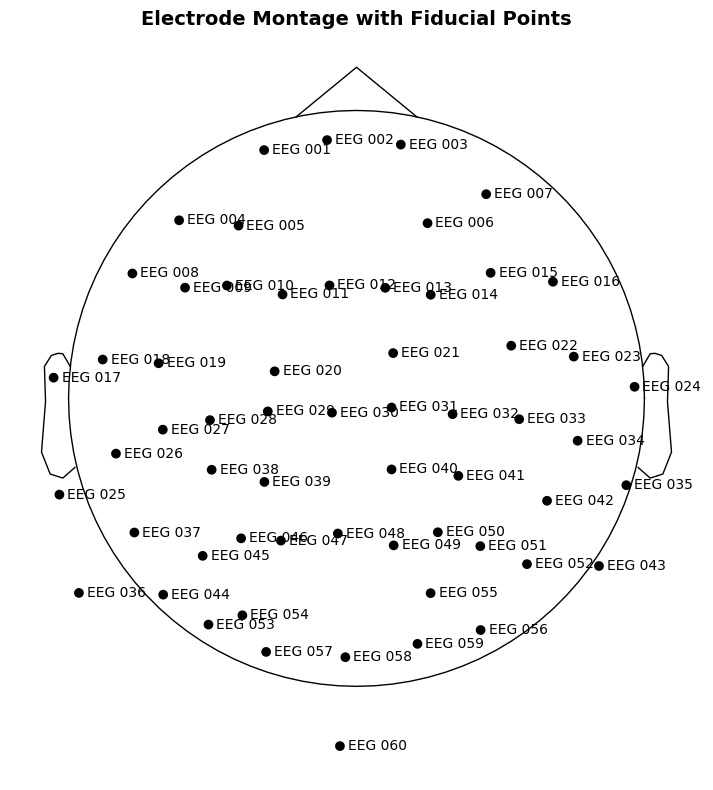


💡 The fiducials define the coordinate system:
   - They're used to align different recordings
   - Essential for group studies and source localization


In [7]:
# Visualize fiducials on the montage
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
mne.viz.plot_montage(montage, show_names=True, kind='topomap', show=False, axes=ax)
ax.set_title('Electrode Montage with Fiducial Points', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n💡 The fiducials define the coordinate system:")
print("   - They're used to align different recordings")
print("   - Essential for group studies and source localization")

In [8]:
# Extract fiducial positions
fiducials = {
    'nasion': pos['nasion'],
    'lpa': pos['lpa'],  # Left preauricular
    'rpa': pos['rpa']   # Right preauricular
}

print("📍 Fiducial Point Positions:")
for name, coords in fiducials.items():
    if coords is not None:
        print(f"   {name.upper():8s}: x={coords[0]:7.4f}, y={coords[1]:7.4f}, z={coords[2]:7.4f} m")
    else:
        print(f"   {name.upper():8s}: Not available")

📍 Fiducial Point Positions:
   NASION  : x= 0.0000, y= 0.1026, z= 0.0000 m
   LPA     : x=-0.0714, y= 0.0000, z= 0.0000 m
   RPA     : x= 0.0753, y= 0.0000, z= 0.0000 m


## **Step 5:** Compare Different Montage Standards
 
 The 10-20 system is just one standard. Let's compare it with other common montages.

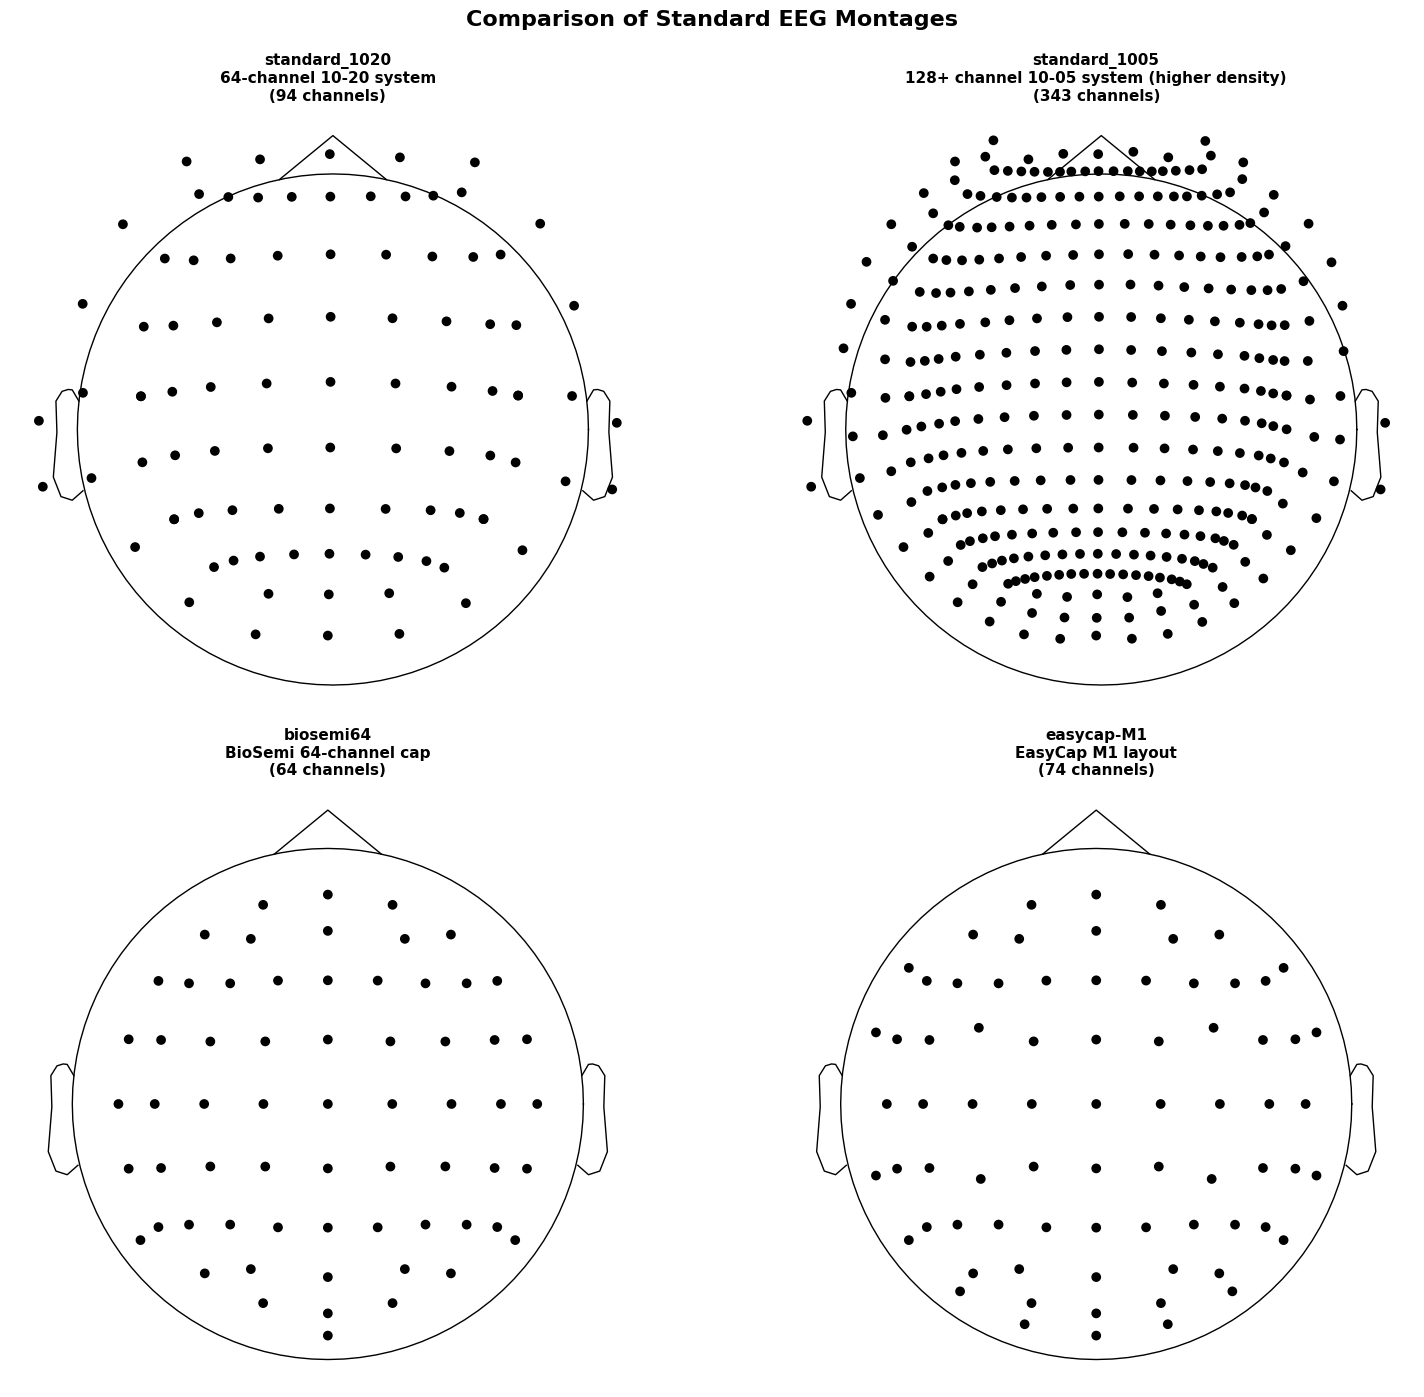


💡 Montage selection considerations:
   - More channels = better spatial resolution
   - More channels = longer setup time
   - 10-20 (64 channels): Good balance for most cognitive studies
   - 10-05 (128+ channels): Better for source localization


In [9]:
# Create a comparison of different standard montages
standard_montages = {
    'standard_1020': '64-channel 10-20 system',
    'standard_1005': '128+ channel 10-05 system (higher density)',
    'biosemi64': 'BioSemi 64-channel cap',
    'easycap-M1': 'EasyCap M1 layout'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (montage_name, description) in enumerate(standard_montages.items()):
    try:
        # Load standard montage
        standard_montage = mne.channels.make_standard_montage(montage_name)
        
        # Create a dummy info object with this montage
        n_channels = len(standard_montage.ch_names)
        info = mne.create_info(
            ch_names=standard_montage.ch_names,
            sfreq=1000,
            ch_types='eeg'
        )
        info.set_montage(standard_montage)
        
        # Plot on subplot
        mne.viz.plot_sensors(info, kind='topomap', show_names=False,
                            axes=axes[idx], show=False)
        axes[idx].set_title(f'{montage_name}\n{description}\n({n_channels} channels)',
                           fontsize=11, weight='bold')
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Montage not available:\n{montage_name}',
                      ha='center', va='center', fontsize=10)
        axes[idx].set_title(f'{montage_name}', fontsize=11, weight='bold')
        axes[idx].axis('off')

plt.suptitle('Comparison of Standard EEG Montages', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 Montage selection considerations:")
print("   - More channels = better spatial resolution")
print("   - More channels = longer setup time")
print("   - 10-20 (64 channels): Good balance for most cognitive studies")
print("   - 10-05 (128+ channels): Better for source localization")


 ### **Useful Commands**
 
 ```python
 # Load/check montage
 montage = raw.get_montage()
 positions = montage.get_positions()
 
 # Visualize in 2D
 mne.viz.plot_sensors(raw.info, kind='topomap', show_names=True)
 
 # Visualize in 3D
 mne.viz.plot_sensors(raw.info, kind='3d')
 
 # Check alignment with head
 mne.viz.plot_alignment(raw.info, subject='fsaverage', 
                        subjects_dir=subjects_dir)
 
 # Set a standard montage
 montage = mne.channels.make_standard_montage('standard_1020')
 raw.set_montage(montage)
 ```
